# Appendix A

In [1]:
#Loading packages
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from scipy.stats import qmc

## General

In [2]:
#Loading shapefile of the catchment area of Mohembo
shapefile_path =  Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/Shapefile" / "CatchmentArea_4326.shp"

#Defining start and end date for ERA5 data
start_date = "1970-01-01T00:00:00Z"
end_date = "2020-12-31T00:00:00Z"

#Creating path for ERA5 data
forcing_path_ERA5 = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/ERA5_HBV/own_shapefile_3"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

#Downloading ERA5 data
#ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset="ERA5",
#   start_time=start_date,
#   end_time=end_date,
#   shape=shapefile_path,
#   directory=forcing_path_ERA5,
#)

#Loading downloaded ERA5 data
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

#Defining start and end date for the calibration period
calibration_start_date = "1975-01-01T00:00:00Z"
calibration_end_date = "2010-12-31T00:00:00Z"

#Loading observed discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

#The model returns data in mm/day, while observed data is in m^3/s
Area_km2 = 173696.852
def mmday_to_m3s(mmday_data, area):
    return (mmday_data * area) / 86.4

## KGE

In [3]:
def KGE(modelled, observed, start, end):
    start = pd.to_datetime(start).tz_localize(None)
    end = pd.to_datetime(end).tz_localize(None)
    
    modelled.index = pd.to_datetime(modelled.index)
    observed.index = pd.to_datetime(observed.index)

    df = pd.concat([modelled.reindex(observed.index, method='ffill'), observed], axis=1, keys=['Modelled', 'Observed'])
    df = df.dropna()
    df = df[(df.index > start) & (df.index < end)]

    r = np.corrcoef(df['Observed'], df['Modelled'])[0, 1]
    beta = np.mean(df['Modelled']) / np.mean(df['Observed'])
    CV_modelled = np.std(df['Modelled']) / np.mean(df['Modelled'])
    CV_observed = np.std(df['Observed']) / np.mean(df['Observed'])                                 
    gamma = CV_modelled / CV_observed
    
    kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (gamma - 1)**2)
    return kge

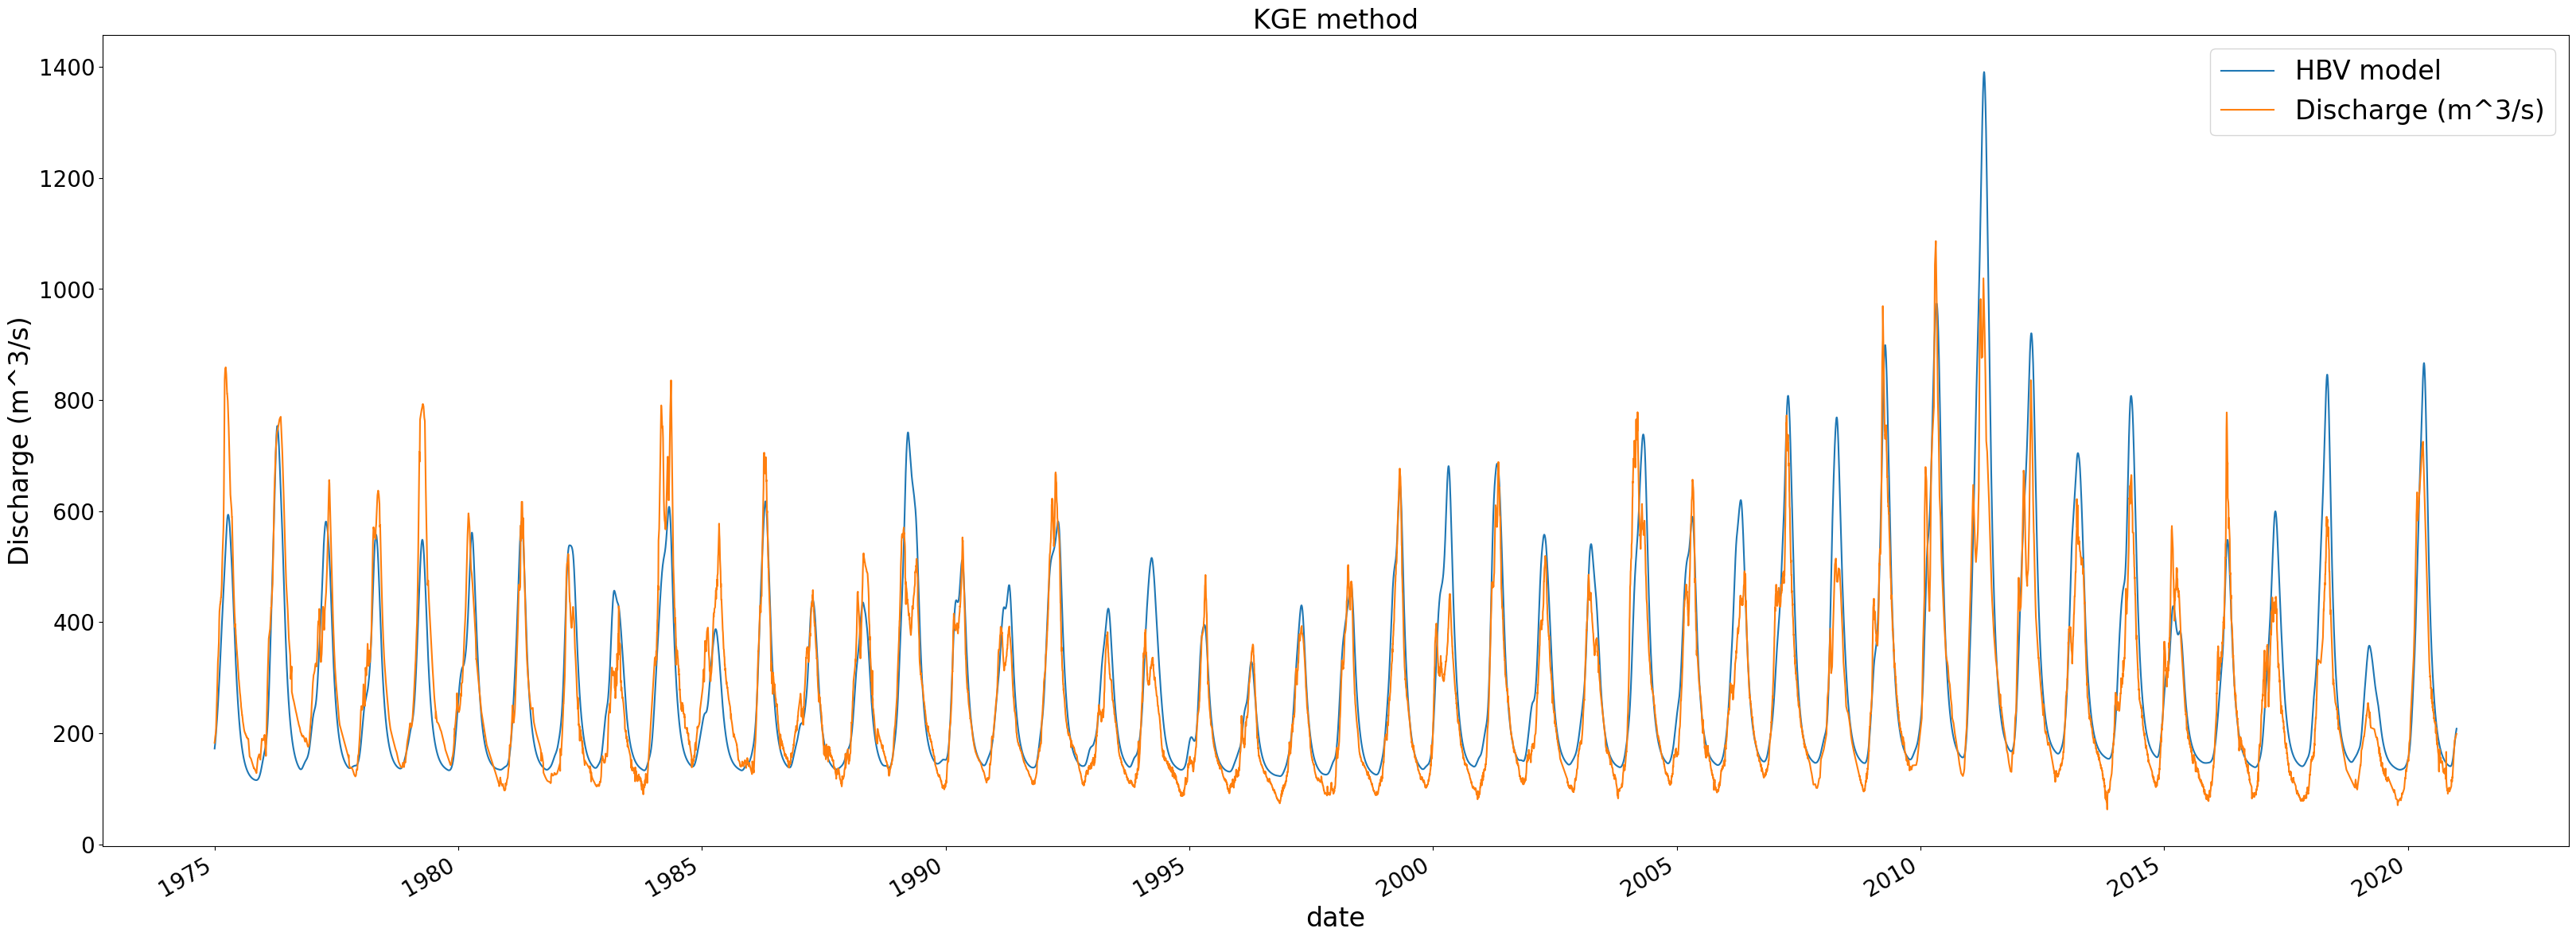

In [4]:
N = 10 #2000 were used to calibrate the parameters, but this takes a long time
s_0 = np.array([0,  100,  0,  5,  0])

param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
param_mins = np.array([0, 0.2, 1000, 0.5, 0.001, 1, 0.0005, 0.00005, 0.00001])
param_maxs = np.array([8, 1.5, 3000, 4, 0.3, 90, 0.1, 0.002, 1])

sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)

#Setting up the HBV model
ensemble = []
for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0)
    ensemble[counter].initialize(config_file)

#Running the model with every generated parameters set
KGE_values = []
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m.append(discharge_this_timestep[0])
        time.append(ensembleMember.time_as_datetime)

    Q_m = mmday_to_m3s(np.array(Q_m), Area_km2)
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))

    #Calculating fit using the KGE function
    KGE_value = KGE(discharge_dataframe['model output'], data_daily['Discharge (m^3/s)'], 
                          calibration_start_date, calibration_end_date)
    KGE_values.append(KGE_value)
    
    del Q_m, time, discharge_dataframe, KGE_value
    
for ensembleMember in ensemble:
    ensembleMember.finalize()

#Retrieving the best parameter set and best KGE value for calibration period
best_index = np.argmax(KGE_values)
best_parameters = parameters[best_index]
best_value = KGE_values[best_index]

best_parameters = [5.692, 0.411, 2413.036, 2.748, 0.264, 52.693, 0.027, 0.001, 0.583]

#Storages       Si,  Su,  Sf, Ss, Sp 
s_0 = np.array([0,  100,  0,  5,  0])

#Running the HBV model
model = ewatercycle.models.HBV(forcing=ERA5_forcing)
config_file, _ = model.setup(parameters=best_parameters, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

#Converting data from mm/day to m^3/s
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('KGE method', fontsize=24)
plt.ylabel("Discharge (m^3/s)");

#Calculating KGE value for calibration period, validation period and whole timeframe
KGE_value_calibration = KGE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2010-12-31T00:00:00Z")
KGE_value_validation = KGE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "2010-01-01T00:00:00Z", "2020-12-31T00:00:00Z")
KGE_value_whole_timeframe = KGE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2020-12-31T00:00:00Z")

|**Parameter**            |**Value**                 |
|-------------------------|--------------------------|
|Imax                     |5.692 mm                  |
|Ce                       |0.411 (-)                 |
|Sumax                    |2413.036 mm               |
|Beta                     |2.748 (-)                 |
|Pmax                     |0.264 mm/day              |
|Tlag                     |52.693 days               |
|Kf                       |0.027 day$^{-1}$          |
|Ks                       |0.001 day$^{-1}$          |
|Fm                       |0.583 (-)                 |

The KGE value corresponding to these parameters is 0.892 for the calibration period and 0.799 for the validation period. For the whole timeframe of the observed data, the KGE value is 0.876.

## Log NSE

In [5]:
def logNSE(modelled, observed, start, end):
    start = pd.to_datetime(start).tz_localize(None)
    end = pd.to_datetime(end).tz_localize(None)
    
    modelled.index = pd.to_datetime(modelled.index)
    observed.index = pd.to_datetime(observed.index)

    df = pd.concat([modelled.reindex(observed.index, method='ffill'), observed], axis=1, keys=['Modelled', 'Observed'])
    df = df.dropna()
    df = df[(df.index > start) & (df.index < end)]

    a = (np.log(df['Modelled']) - np.log(df['Observed']))**2
    a1 = a.sum() 
    b = (np.log(df['Observed']) - np.log(np.mean(df['Observed'])))**2
    b1 = b.sum()
    lognse = 1 - (a1/b1)
    return lognse

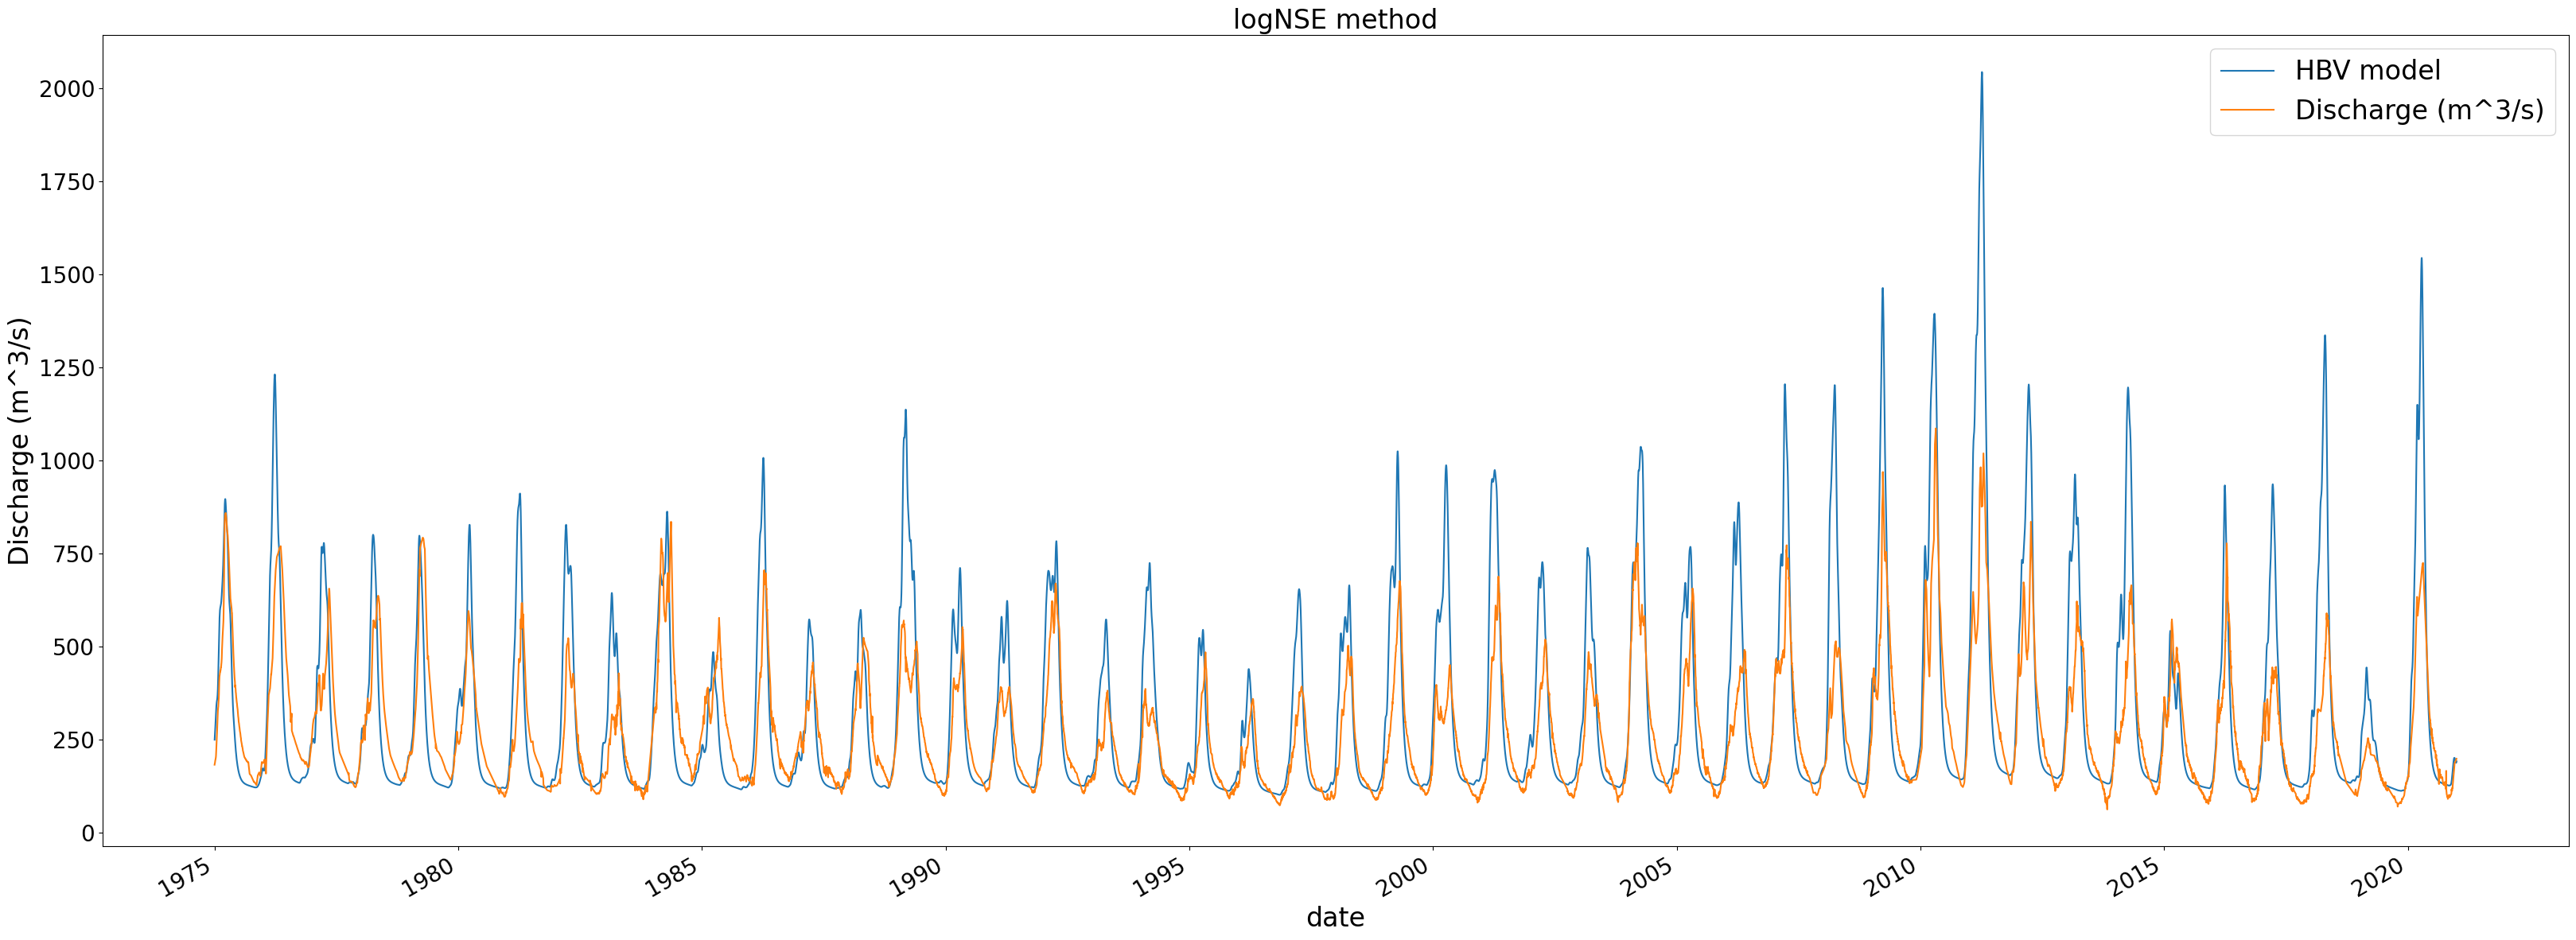

In [6]:
N = 10 #2000 were used to calibrate the parameters, but this takes a long time
s_0 = np.array([0,  100,  0,  5,  0])

param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
param_mins = np.array([0, 0.2, 1000, 0.5, 0.001, 1, 0.0005, 0.00005, 0.00001])
param_maxs = np.array([8, 1.5, 3000, 4, 0.3, 90, 0.1, 0.002, 1])

sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)

#Setting up the HBV model
ensemble = []
for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0)
    ensemble[counter].initialize(config_file)

#Running the model with every generated parameters set
logNSE_values = []
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m.append(discharge_this_timestep[0])
        time.append(ensembleMember.time_as_datetime)

    Q_m = mmday_to_m3s(np.array(Q_m), Area_km2)
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))

    #Calculating fit using the logNSE function
    logNSE_value = logNSE(discharge_dataframe['model output'], data_daily['Discharge (m^3/s)'], 
                          calibration_start_date, calibration_end_date)
    logNSE_values.append(logNSE_value)
    
    del Q_m, time, discharge_dataframe, logNSE_value
    
for ensembleMember in ensemble:
    ensembleMember.finalize()

#Retrieving the best parameter set and best logNSE value for calibration period
best_index = np.argmax(logNSE_values)
best_parameters = parameters[best_index]
best_value = logNSE_values[best_index]

best_parameters = [7.116, 0.355, 1668.678, 2.525, 0.284, 21.84, 0.044, 0.002, 0.786]

#Storages       Si,  Su,  Sf, Ss, Sp 
s_0 = np.array([0,  100,  0,  5,  0])

#Running the HBV model
model = ewatercycle.models.HBV(forcing=ERA5_forcing)
config_file, _ = model.setup(parameters=best_parameters, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

#Converting data from mm/day to m^3/s
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('logNSE method', fontsize=24)
plt.ylabel("Discharge (m^3/s)");

#Calculating logNSE value for calibration period, validation period and whole timeframe
logNSE_value_calibration = logNSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2010-12-31T00:00:00Z")
logNSE_value_validation = logNSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "2010-01-01T00:00:00Z", "2020-12-31T00:00:00Z")
logNSE_value_whole_timeframe = logNSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2020-12-31T00:00:00Z")

|**Parameter**            |**Value**                 |
|-------------------------|--------------------------|
|Imax                     |7.116 mm                  |
|Ce                       |0.355 (-)                 |
|Sumax                    |1668.678 mm               |
|Beta                     |2.525 (-)                 |
|Pmax                     |0.284 mm/day              |
|Tlag                     |21.84 days                |
|Kf                       |0.044 day$^{-1}$          |
|Ks                       |0.002 day$^{-1}$          |
|Fm                       |0.786 (-)                 |

The log-NSE value corresponding to these parameters is 0.609 for the calibration period and 0.682 for the validation period. For the whole timeframe of the observed data, the log-NSE value is 0.625.

## RMSE

In [7]:
def RMSE(modelled, observed, start, end):
    start = pd.to_datetime(start).tz_localize(None)
    end = pd.to_datetime(end).tz_localize(None)
    
    modelled.index = pd.to_datetime(modelled.index)
    observed.index = pd.to_datetime(observed.index)

    df = pd.concat([modelled.reindex(observed.index, method='ffill'), observed], axis=1, keys=['Modelled', 'Observed'])
    df = df.dropna()
    df = df[(df.index > start) & (df.index < end)]

    n = len(df)
    a = (df['Observed'] - df['Modelled'])**2
    a1 = a.sum()
    rmse = np.sqrt(a1 / n)
    return rmse

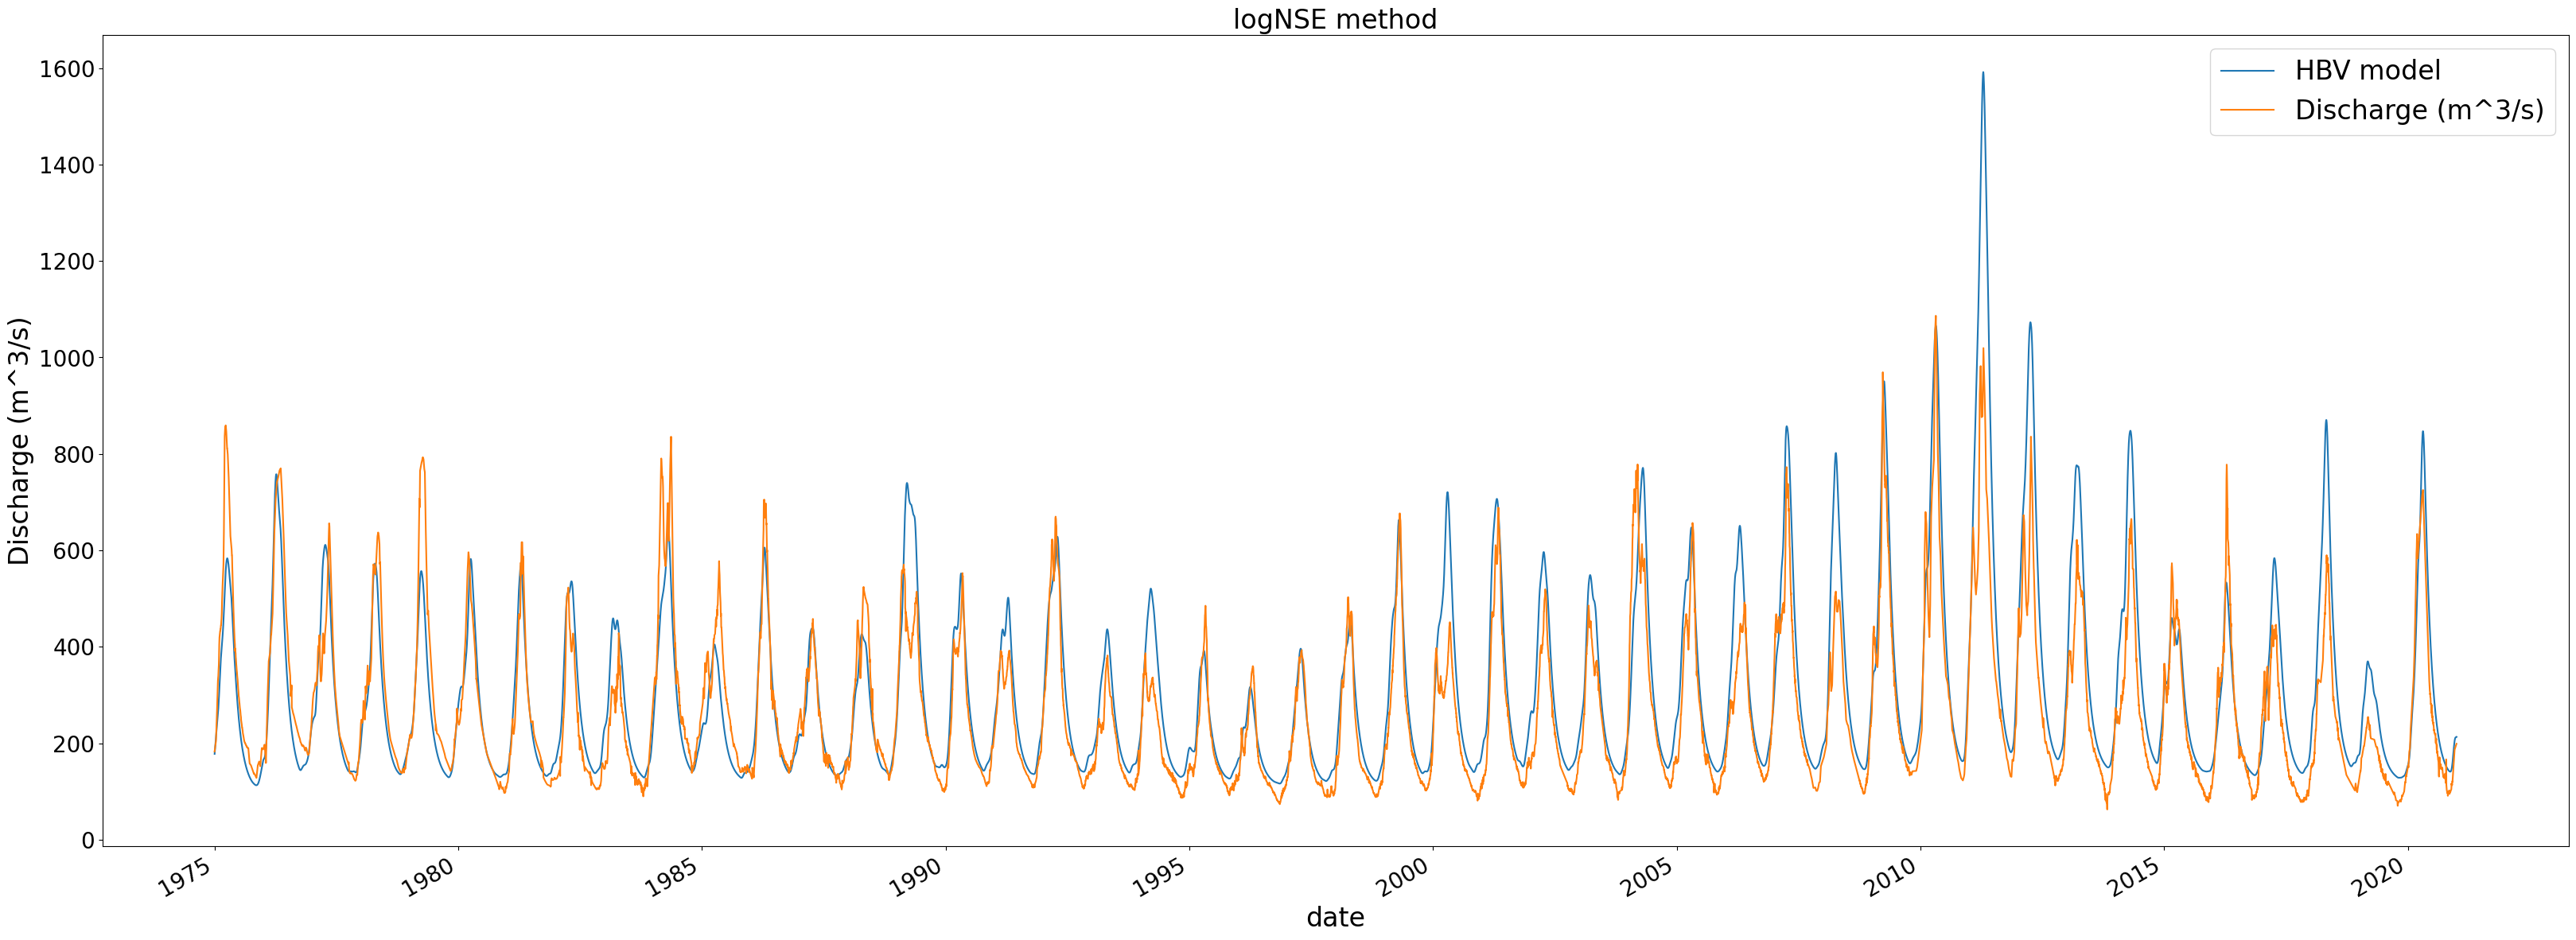

In [8]:
N = 10 #2000 were used to calibrate the parameters, but this takes a long time
s_0 = np.array([0,  100,  0,  5,  0])

param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
param_mins = np.array([0, 0.2, 1000, 0.5, 0.001, 1, 0.0005, 0.00005, 0.00001])
param_maxs = np.array([8, 1.5, 3000, 4, 0.3, 90, 0.1, 0.002, 1])

sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)

#Setting up the HBV model
ensemble = []
for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0)
    ensemble[counter].initialize(config_file)

#Running the model with every generated parameters set
RMSE_values = []
for ensembleMember in ensemble:
    Q_m = []
    time = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m.append(discharge_this_timestep[0])
        time.append(ensembleMember.time_as_datetime)

    Q_m = mmday_to_m3s(np.array(Q_m), Area_km2)
    discharge_dataframe = pd.DataFrame({'model output': Q_m}, index=pd.to_datetime(time))

    #Calculating fit using the RMSE function
    RMSE_value = RMSE(discharge_dataframe['model output'], data_daily['Discharge (m^3/s)'], 
                          calibration_start_date, calibration_end_date)
    RMSE_values.append(RMSE_value)
    
    del Q_m, time, discharge_dataframe, RMSE_value
    
for ensembleMember in ensemble:
    ensembleMember.finalize()

#Retrieving the best parameter set and best RMSE value for calibration period
best_index = np.argmax(RMSE_values)
best_parameters = parameters[best_index]
best_value = RMSE_values[best_index]

best_parameters = [5.242, 0.594, 2411.181, 3.518, 0.167, 34.311, 0.019, 0.001, 0.377]

#Storages       Si,  Su,  Sf, Ss, Sp 
s_0 = np.array([0,  100,  0,  5,  0])

#Running the HBV model
model = ewatercycle.models.HBV(forcing=ERA5_forcing)
config_file, _ = model.setup(parameters=best_parameters, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

#Converting data from mm/day to m^3/s
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('logNSE method', fontsize=24)
plt.ylabel("Discharge (m^3/s)");

#Calculating RMSE value for calibration period, validation period and whole timeframe
RMSE_value_calibration = RMSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2010-12-31T00:00:00Z")
RMSE_value_validation = RMSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "2010-01-01T00:00:00Z", "2020-12-31T00:00:00Z")
RMSE_value_whole_timeframe = RMSE(Q_model_pd, data_daily['Discharge (m^3/s)'], 
                          "1975-01-01T00:00:00Z", "2020-12-31T00:00:00Z")

|**Parameter**            |**Value**                 |
|-------------------------|--------------------------|
|Imax                     |5.242 mm                  |
|Ce                       |0.594 (-)                 |
|Sumax                    |2411.181 mm               |
|Beta                     |3.518 (-)                 |
|Pmax                     |0.167 mm/day              |
|Tlag                     |34.311 days               |
|Kf                       |0.019 day$^{-1}$          |
|Ks                       |0.001 day$^{-1}$          |
|Fm                       |0.377 (-)                 |

The RMSE value corresponding to these parameters is 75.893 m3/day for the calibration period and 138.179 m3/day for the validation period. For the whole timeframe of the observed data, the RMSE value is 94.213 m3/day.